# 12. XGBoost — Feature Selection & Final Model

## 목적
- `features_final.csv` 전체 피처로 XGBoost 학습 (GroupKFold)
- SHAP 기반 feature selection (XGBoost 자체)
- 선정된 피처로 최종 모델 + LightGBM 비교

## 입력
- `features_final.csv` (피처 only)
- `labels_final.csv` (ID + 레이블)

## 출력
- XGBoost SHAP feature importance
- Ablation → 최적 피처셋
- OOF AUROC / AUPRC
- `xgb_selected_features.csv`

In [ ]:

from pathlib import Path
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report,
    confusion_matrix,
)
import xgboost as xgb
import lightgbm as lgb
import shap

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

TARGET = 'composite_next_24h'
N_SPLITS     = 5
N_SPLITS_ABL = 3

def _detect_xgb_gpu() -> bool:
    try:
        d = xgb.DMatrix(np.zeros((16, 2)))
        xgb.train(
            {'device': 'cuda', 'tree_method': 'hist', 'verbosity': 0},
            d, num_boost_round=1,
        )
        return True
    except Exception:
        return False

USE_GPU = _detect_xgb_gpu()

if USE_GPU:
    print('GPU 감지: CUDA 사용 (device=cuda)')
else:
    print('GPU 없음: CPU 사용 (n_jobs=-1)')

print('=== 12. XGBoost — Feature Selection & Final Model ===')

GPU 없음: CPU 사용 (n_jobs=-1)
=== 12. XGBoost — Feature Selection & Final Model ===


## Step 1: 데이터 로드 (features_final 전체)

In [4]:
print('Step 1: 데이터 로드')

df_features = pd.read_csv(f'{PROCESSED_DIR}/features_final.csv')
df_labels = pd.read_csv(f'{PROCESSED_DIR}/labels_final.csv')

print(f'features_final: {len(df_features):,} rows, {len(df_features.columns)} cols')
print(f'labels_final: {len(df_labels):,} rows, {len(df_labels.columns)} cols')
print(f'환자: {df_labels["stay_id"].nunique():,}명')

assert len(df_features) == len(df_labels), 'features/labels row mismatch'

# ── 중복 컬럼 처리 (observation_hour.1 등 pandas 자동 rename 산물) ────────────
obs_hour_dups = [c for c in df_features.columns if c.startswith('observation_hour.')]
if obs_hour_dups:
    print(f'\n⚠️  observation_hour 중복 컬럼 감지: {obs_hour_dups} → 제거')
    df_features = df_features.drop(columns=obs_hour_dups)

# ── icu_mortality: temporal leakage 확인 후 제거 ─────────────────────────────
# composite_next_24h = 향후 24h 내 사망/기계환기/승압제
# icu_mortality      = ICU 재원 중 사망 여부 (퇴실 시점 결과값)
#   → 현재 observation 시점보다 훨씬 미래 정보 포함 가능 → 시간적 leakage
if 'icu_mortality' in df_features.columns:
    print(f'\n⚠️  icu_mortality 감지:')
    print(f'    composite_next_24h와 시간적 leakage 가능성 존재')
    print(f'    (ICU 최종 사망 여부 → 미래 결과값을 현재 피처로 사용 불가)')
    print(f'    → icu_mortality 제거')
    df_features = df_features.drop(columns=['icu_mortality'])

# ID / 레이블 분리
label_cols = [c for c in df_labels.columns if 'next_' in c]
id_cols = ['stay_id', 'subject_id', 'hadm_id', 'observation_hour',
           'observation_start', 'observation_end']
feature_cols = df_features.columns.tolist()

print(f'\n피처: {len(feature_cols)}개')
print(f'레이블: {label_cols}')
print(f'\n타겟 분포 ({TARGET}):')
print(f'  0: {(df_labels[TARGET]==0).sum():,} ({(df_labels[TARGET]==0).mean()*100:.1f}%)')
print(f'  1: {(df_labels[TARGET]==1).sum():,} ({(df_labels[TARGET]==1).mean()*100:.1f}%)')

Step 1: 데이터 로드


features_final: 158,985 rows, 53 cols
labels_final: 158,985 rows, 18 cols
환자: 4,713명

피처: 53개
레이블: ['death_next_6h', 'vent_next_6h', 'pressor_next_6h', 'composite_next_6h', 'death_next_12h', 'vent_next_12h', 'pressor_next_12h', 'composite_next_12h', 'death_next_24h', 'vent_next_24h', 'pressor_next_24h', 'composite_next_24h']

타겟 분포 (composite_next_24h):
  0: 145,985 (91.8%)
  1: 13,000 (8.2%)


## Step 2: 고상관 피처 제거 (r > 0.95)

> Tree 모델은 다중공선성에 강건하므로 완전 중복(r > 0.95)만 제거.

In [5]:
print('Step 2: 고상관 피처 제거')

corr = df_features[feature_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if val > 0.95:
            high_pairs.append((idx, col, val))
high_pairs.sort(key=lambda x: -x[2])

print(f'r > 0.95 쌍: {len(high_pairs)}개')
for a, b, r in high_pairs:
    print(f'  {a} <-> {b}: r={r:.3f}')

drop_high_corr = set()
for a, b, r in high_pairs:
    if a not in drop_high_corr:
        drop_high_corr.add(b)

if drop_high_corr:
    print(f'\n제거: {drop_high_corr}')
    feature_cols = [c for c in feature_cols if c not in drop_high_corr]

print(f'-> 남은 피처: {len(feature_cols)}개')

Step 2: 고상관 피처 제거


r > 0.95 쌍: 2개
  spo2 <-> spo2_min: r=1.000
  sbp <-> sbp_min: r=1.000

제거: {'sbp_min', 'spo2_min'}
-> 남은 피처: 51개


## Step 3: XGBoost Baseline (전체 피처, GroupKFold)

> 환자 단위 GroupKFold로 data leakage 방지.  
> `scale_pos_weight`로 클래스 불균형 보정.

In [6]:
print('Step 3: XGBoost Baseline (전체 피처)')

X = df_features[feature_cols].values
y = df_labels[TARGET].values
groups = df_labels['stay_id'].values

pos_rate = y.mean()
scale_pos = (1 - pos_rate) / pos_rate
print(f'positive rate: {pos_rate:.4f}, scale_pos_weight: {scale_pos:.1f}')

xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'tree_method':      'hist',
    'learning_rate':    0.05,
    'max_depth':        7,
    'min_child_weight': 50,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'scale_pos_weight': scale_pos,
    'seed':             42,
    'verbosity':        0,
}

if USE_GPU:
    xgb_params.update({'device': 'cuda', 'max_bin': 256})
    print('XGBoost: GPU(cuda), max_bin=256')
else:
    xgb_params.update({'device': 'cpu', 'nthread': -1})
    print('XGBoost: CPU, nthread=-1')

print('eval_metric: auc | num_boost_round=1000 | early_stopping=50')

gkf = GroupKFold(n_splits=N_SPLITS)

oof_preds_all = np.zeros(len(df_features))
fold_metrics_all = []
models_all = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=feature_cols)
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=feature_cols)

    model = xgb.train(
        xgb_params, dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    val_pred = model.predict(dval)
    oof_preds_all[val_idx] = val_pred

    auroc = roc_auc_score(y_val, val_pred)
    auprc = average_precision_score(y_val, val_pred)
    fold_metrics_all.append({
        'fold': fold, 'auroc': auroc, 'auprc': auprc,
        'best_iter': model.best_iteration
    })
    models_all.append(model)
    print(f'  Fold {fold}: AUROC={auroc:.4f}, AUPRC={auprc:.4f} (iter={model.best_iteration})')

baseline_auroc = roc_auc_score(y, oof_preds_all)
baseline_auprc = average_precision_score(y, oof_preds_all)
print(f'\n=== Baseline OOF ({len(feature_cols)} features) ===')
print(f'  AUROC: {baseline_auroc:.4f}')
print(f'  AUPRC: {baseline_auprc:.4f}')

Step 3: XGBoost Baseline (전체 피처)
positive rate: 0.0818, scale_pos_weight: 11.2
XGBoost: CPU, nthread=-1
eval_metric: auc | num_boost_round=1000 | early_stopping=50
  Fold 0: AUROC=0.9153, AUPRC=0.6037 (iter=119)
  Fold 1: AUROC=0.9154, AUPRC=0.6189 (iter=94)
  Fold 2: AUROC=0.8817, AUPRC=0.5189 (iter=23)
  Fold 3: AUROC=0.9000, AUPRC=0.5820 (iter=117)
  Fold 4: AUROC=0.8835, AUPRC=0.5273 (iter=157)

=== Baseline OOF (51 features) ===
  AUROC: 0.8977
  AUPRC: 0.5686


Confusion Matrix @ threshold=0.50


,pred_0,pred_1
true_0,133447,12538
true_1,3982,9018


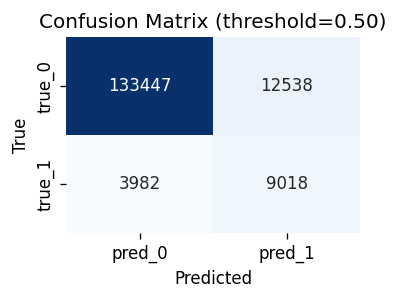

In [7]:
# Confusion Matrix (OOF)
threshold = 0.5
y_pred = (oof_preds_all >= threshold).astype(int)
cm = confusion_matrix(y, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['true_0', 'true_1'], columns=['pred_0', 'pred_1'])
print(f'Confusion Matrix @ threshold={threshold:.2f}')
display(cm_df)

plt.figure(figsize=(3.2, 2.6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (threshold={threshold:.2f})')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [8]:
df_metrics_all = pd.DataFrame(fold_metrics_all)
print('=== Baseline Fold별 결과 ===')
print(df_metrics_all.to_string(index=False))
print(f'\nAUROC mean: {df_metrics_all["auroc"].mean():.4f} +/- {df_metrics_all["auroc"].std():.4f}')
print(f'AUPRC mean: {df_metrics_all["auprc"].mean():.4f} +/- {df_metrics_all["auprc"].std():.4f}')

=== Baseline Fold별 결과 ===
 fold    auroc    auprc  best_iter
    0 0.915318 0.603668        119
    1 0.915368 0.618937         94
    2 0.881730 0.518918         23
    3 0.899975 0.581978        117
    4 0.883460 0.527260        157

AUROC mean: 0.8992 +/- 0.0164
AUPRC mean: 0.5702 +/- 0.0450


## Step 4: SHAP 분석 (XGBoost)

> XGBoost TreeExplainer로 SHAP 계산 → 피처 중요도 순위 도출

In [9]:
print('Step 4: SHAP 분석')

last_fold_val_idx = list(gkf.split(X, y, groups))[-1][1]
X_shap = df_features.iloc[last_fold_val_idx][feature_cols]

max_samples = min(2000, len(X_shap))   # 5000→2000: 피처 순위에 충분, ~2.5x 빠름
X_shap_sample = X_shap.sample(max_samples, random_state=42)

explainer = shap.TreeExplainer(models_all[-1])
shap_values = explainer.shap_values(X_shap_sample)

print(f'SHAP 샘플: {max_samples}개 | shape: {shap_values.shape}')

Step 4: SHAP 분석
SHAP 샘플: 2000개 | shape: (2000, 51)


=== SHAP Summary Plot ===


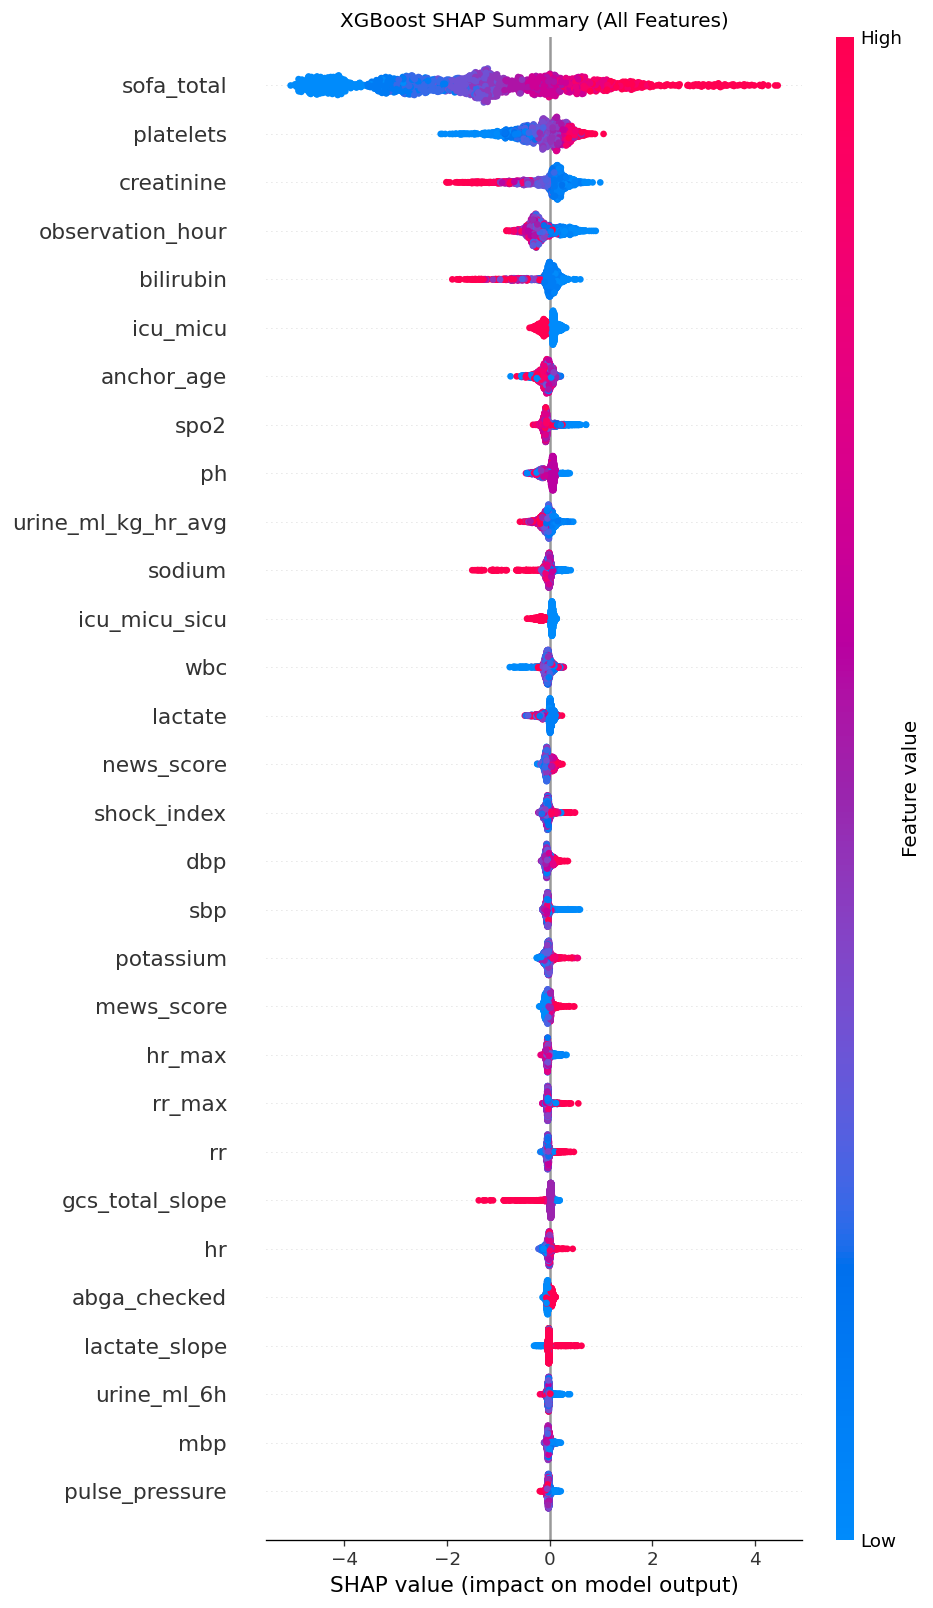

In [10]:
print('=== SHAP Summary Plot ===')
fig, ax = plt.subplots(figsize=(10, 12))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_cols,
                  max_display=30, show=False)
plt.title('XGBoost SHAP Summary (All Features)')
plt.tight_layout()
plt.show()

=== XGBoost SHAP Feature Importance (전체) ===
           feature  mean_abs_shap
        sofa_total       2.000057
         platelets       0.358278
        creatinine       0.308847
  observation_hour       0.271293
         bilirubin       0.178311
          icu_micu       0.123020
        anchor_age       0.110611
              spo2       0.105578
                ph       0.098865
urine_ml_kg_hr_avg       0.091623
            sodium       0.085230
     icu_micu_sicu       0.084442
               wbc       0.074076
           lactate       0.073562
        news_score       0.066649
       shock_index       0.065723
               dbp       0.060011
               sbp       0.059978
         potassium       0.059645
        mews_score       0.058298
            hr_max       0.053533
            rr_max       0.050169
                rr       0.049733
   gcs_total_slope       0.048724
                hr       0.042251
      abga_checked       0.041925
     lactate_slope       0.036254
   

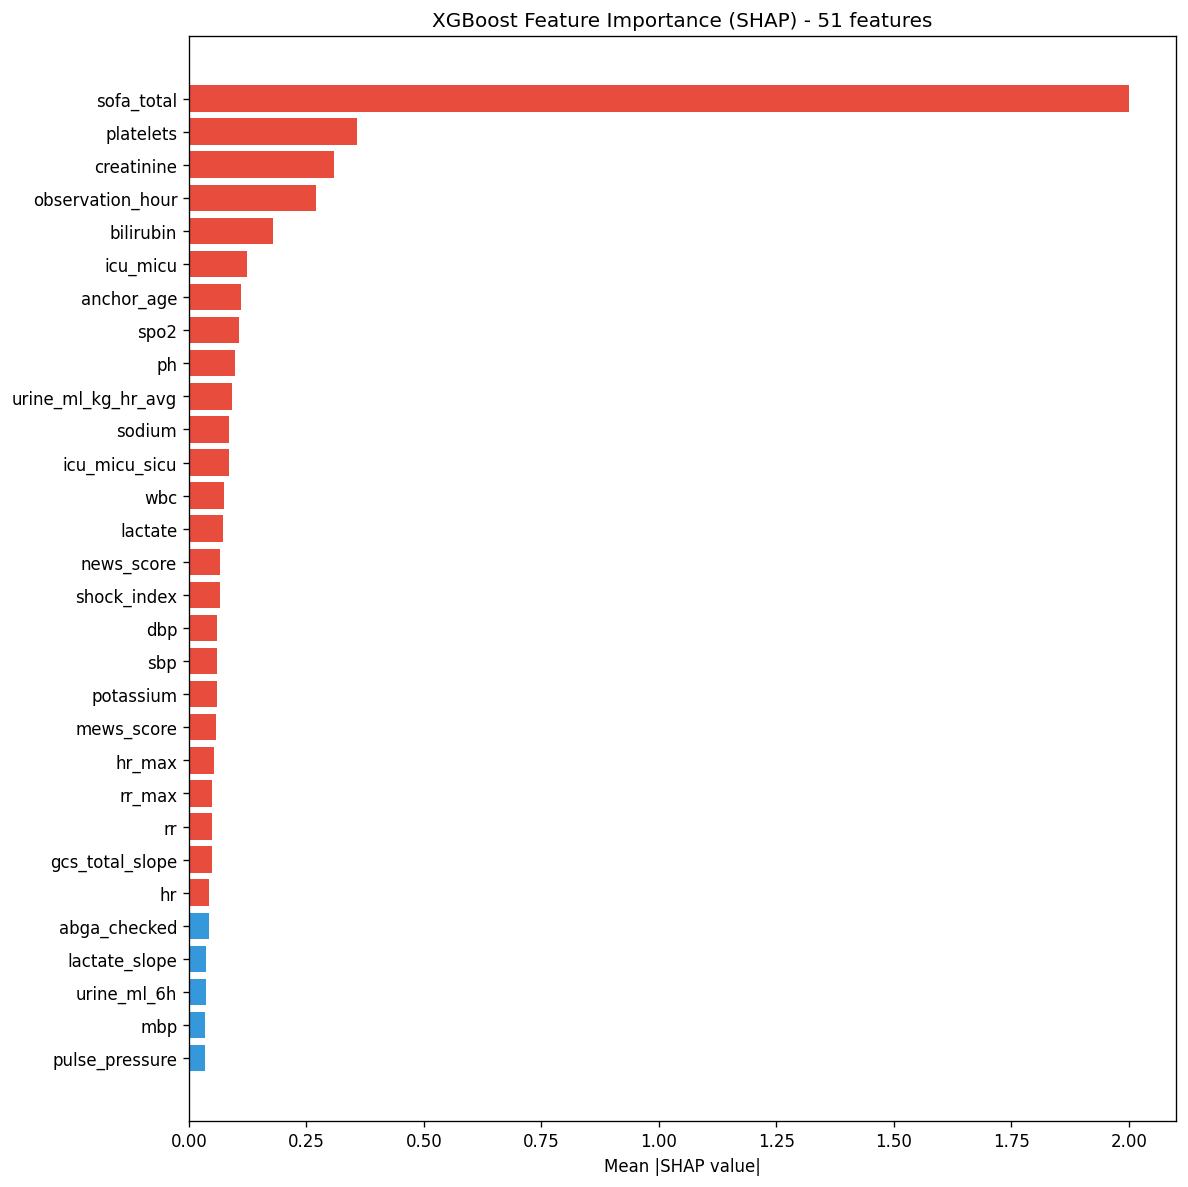


=== SHAP 기반 분류 (threshold: max*0.5% = 0.0100) ===
  유효 피처 (>= threshold): 42개
  제거 후보 (< threshold):  9개

  제거 후보:
    urine_missing: 0.009767
    gcs_motor: 0.007908
    spo2_slope: 0.005635
    sbp_slope: 0.003384
    rr_slope: 0.003365
    oliguria_flag: 0.003282
    creatinine_slope: 0.002879
    icu_tsicu: 0.002851
    map_below_65: 0.000191


In [11]:
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('=== XGBoost SHAP Feature Importance (전체) ===')
print(shap_importance.to_string(index=False))

# SHAP bar plot
fig, ax = plt.subplots(figsize=(10, 10))
top_n = min(30, len(shap_importance))
data = shap_importance.head(top_n).iloc[::-1]
colors = ['#e74c3c' if v > shap_importance['mean_abs_shap'].median() else '#3498db'
          for v in data['mean_abs_shap']]
ax.barh(data['feature'], data['mean_abs_shap'], color=colors)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'XGBoost Feature Importance (SHAP) - {len(feature_cols)} features')
plt.tight_layout()
plt.show()

# 하위 피처 식별 (threshold: max * 0.5%)
threshold = shap_importance['mean_abs_shap'].max() * 0.005
low_shap = shap_importance[shap_importance['mean_abs_shap'] < threshold]
high_shap = shap_importance[shap_importance['mean_abs_shap'] >= threshold]

print(f'\n=== SHAP 기반 분류 (threshold: max*0.5% = {threshold:.4f}) ===')
print(f'  유효 피처 (>= threshold): {len(high_shap)}개')
print(f'  제거 후보 (< threshold):  {len(low_shap)}개')
if len(low_shap) > 0:
    print(f'\n  제거 후보:')
    for _, row in low_shap.iterrows():
        print(f'    {row["feature"]}: {row["mean_abs_shap"]:.6f}')

## Step 5: Ablation Study (SHAP 하위 피처 제거)

> SHAP 중요도 하위 피처를 5개씩 제거하며 OOF AUROC 추적.  
> 성능이 꺾이는 지점 = 최적 피처 수.

In [12]:
print('Step 5: Ablation Study (XGBoost)')

MANDATORY_CLINICAL = ['lactate', 'gcs_total', 'shock_index', 'sbp',
                      'wbc', 'creatinine', 'ph', 'sofa_total']
MANDATORY_FEATURES = [f for f in MANDATORY_CLINICAL if f in feature_cols]
missing_mandatory  = [f for f in MANDATORY_CLINICAL if f not in feature_cols]

print(f'임상 필수 변수 ({len(MANDATORY_FEATURES)}개, 강제 포함): {MANDATORY_FEATURES}')
if missing_mandatory:
    print(f'  ⚠️  피처 목록에 없는 필수 변수: {missing_mandatory}')

ranked_features  = shap_importance['feature'].tolist()
optional_ranked  = [f for f in ranked_features if f not in MANDATORY_FEATURES]
print(f'SHAP 기반 optional 변수 ({len(optional_ranked)}개): ablation 대상')

gkf_abl = GroupKFold(n_splits=N_SPLITS_ABL)

step_size = 10
ablation_results = []

ablation_results.append({
    'n_features': len(ranked_features),
    'removed': 'none',
    'auroc': baseline_auroc,
    'auprc': baseline_auprc,
})

for n_remove in range(step_size, len(optional_ranked) - step_size, step_size):
    keep_optional = optional_ranked[:len(optional_ranked) - n_remove]
    keep_features = MANDATORY_FEATURES + keep_optional

    X_sub = df_features[keep_features].values
    oof_sub = np.zeros(len(df_features))

    for fold, (train_idx, val_idx) in enumerate(gkf_abl.split(X_sub, y, groups)):
        X_tr, X_val = X_sub[train_idx], X_sub[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=keep_features)
        dval   = xgb.DMatrix(X_val, label=y_val, feature_names=keep_features)

        model = xgb.train(
            xgb_params, dtrain,
            num_boost_round=1000,
            evals=[(dval, 'val')],
            early_stopping_rounds=50,
            verbose_eval=False,
        )
        oof_sub[val_idx] = model.predict(dval)

    val_mask = oof_sub > 0
    auroc_sub = roc_auc_score(y[val_mask], oof_sub[val_mask])
    auprc_sub = average_precision_score(y[val_mask], oof_sub[val_mask])

    ablation_results.append({
        'n_features': len(keep_features),
        'removed': f'bottom {n_remove} optional',
        'auroc': auroc_sub,
        'auprc': auprc_sub,
    })

    delta = auroc_sub - baseline_auroc
    marker = '***' if delta < -0.005 else ''
    print(f'  {len(keep_features):2d} feat (opt={len(keep_optional)}): '
          f'AUROC={auroc_sub:.4f} ({delta:+.4f}) AUPRC={auprc_sub:.4f} {marker}')

df_ablation = pd.DataFrame(ablation_results)

Step 5: Ablation Study (XGBoost)
임상 필수 변수 (8개, 강제 포함): ['lactate', 'gcs_total', 'shock_index', 'sbp', 'wbc', 'creatinine', 'ph', 'sofa_total']
SHAP 기반 optional 변수 (43개): ablation 대상
  41 feat (opt=33): AUROC=0.8981 (+0.0004) AUPRC=0.5613 
  31 feat (opt=23): AUROC=0.8975 (-0.0002) AUPRC=0.5600 
  21 feat (opt=13): AUROC=0.8935 (-0.0042) AUPRC=0.5479 


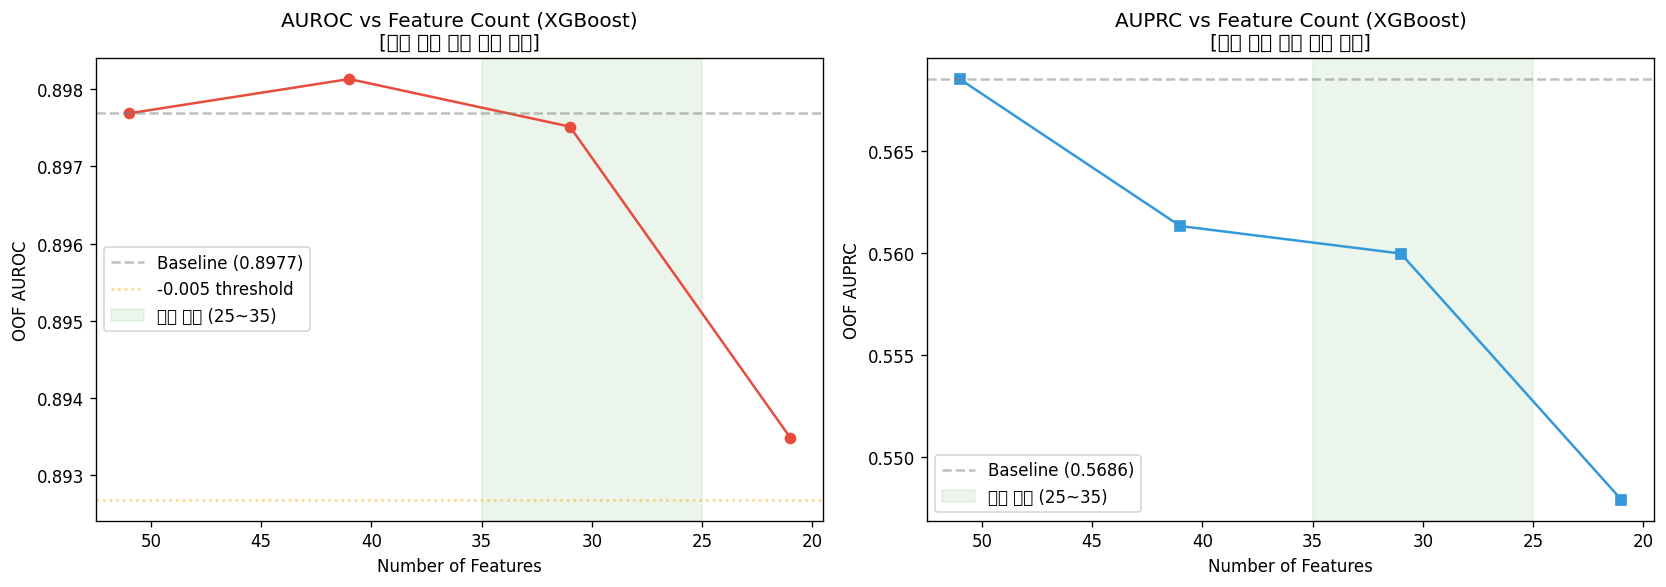


최적 피처 수: 31개
  (AUROC >= 0.8927 조건 만족 & 25~35 범위 내 최소 피처)
  임상 필수: 8개 | optional: 23개

  Ablation 결과 요약:
 n_features    auroc    auprc
         51 0.897687 0.568561
         41 0.898131 0.561336
         31 0.897516 0.559984
         21 0.893487 0.547889


In [13]:
# Ablation 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_ablation['n_features'], df_ablation['auroc'], 'o-', color='#e74c3c')
axes[0].axhline(baseline_auroc, color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_auroc:.4f})')
axes[0].axhline(baseline_auroc - 0.005, color='orange', linestyle=':', alpha=0.5, label='-0.005 threshold')
axes[0].axvspan(25, 35, alpha=0.08, color='green', label='목표 범위 (25~35)')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('OOF AUROC')
axes[0].set_title('AUROC vs Feature Count (XGBoost)\n[임상 필수 변수 강제 포함]')
axes[0].legend()
axes[0].invert_xaxis()

axes[1].plot(df_ablation['n_features'], df_ablation['auprc'], 's-', color='#3498db')
axes[1].axhline(baseline_auprc, color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_auprc:.4f})')
axes[1].axvspan(25, 35, alpha=0.08, color='green', label='목표 범위 (25~35)')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('OOF AUPRC')
axes[1].set_title('AUPRC vs Feature Count (XGBoost)\n[임상 필수 변수 강제 포함]')
axes[1].legend()
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

# ── 최적 피처 수 결정 ─────────────────────────────────────────────────────
# 기준 1: AUROC baseline -0.005 이내
# 기준 2: 25~35개 범위 목표
threshold_auroc = baseline_auroc - 0.005
valid = df_ablation[df_ablation['auroc'] >= threshold_auroc].sort_values('n_features')

# 25~35 범위 내 찾기
in_range = valid[(valid['n_features'] >= 25) & (valid['n_features'] <= 35)]

if len(in_range) > 0:
    optimal_n = int(in_range.sort_values('n_features').iloc[0]['n_features'])
    print(f'\n최적 피처 수: {optimal_n}개')
    print(f'  (AUROC >= {threshold_auroc:.4f} 조건 만족 & 25~35 범위 내 최소 피처)')
else:
    # 범위 밖: 35개 이하 중 AUROC 조건 만족하는 최소
    below35 = valid[valid['n_features'] <= 35]
    if len(below35) > 0:
        optimal_n = int(below35.sort_values('n_features').iloc[0]['n_features'])
        print(f'\n최적 피처 수: {optimal_n}개')
        print(f'  (25~35 범위 결과 없음 → 35 이하 최소, AUROC >= {threshold_auroc:.4f})')
    elif len(valid) > 0:
        # 35개 초과지만 AUROC 조건 만족하는 최소
        optimal_n = int(valid.sort_values('n_features').iloc[0]['n_features'])
        print(f'\n최적 피처 수: {optimal_n}개')
        print(f'  (AUROC 조건 만족하는 최소, 범위 조정 필요)')
    else:
        # AUROC 조건 만족 없음: baseline에 가장 가까운 30개 부근 선택
        closest = df_ablation.iloc[(df_ablation['n_features'] - 30).abs().argsort()[:1]]
        optimal_n = int(closest['n_features'].values[0])
        print(f'\n최적 피처 수: {optimal_n}개 (AUROC 조건 미달, 30개 근방 fallback)')

print(f'  임상 필수: {len(MANDATORY_FEATURES)}개 | optional: {optimal_n - len(MANDATORY_FEATURES)}개')
print(f'\n  Ablation 결과 요약:')
print(df_ablation[['n_features', 'auroc', 'auprc']].to_string(index=False))

In [14]:
# Step 3 baseline이 이미 전체 피처(51개)로 학습된 결과 — 재학습 없이 재사용
print('=== 최종 모델 = Step 3 Baseline (전체 피처 51개) ===')

oof_final        = oof_preds_all
final_auroc      = baseline_auroc
final_auprc      = baseline_auprc
fold_metrics_final = fold_metrics_all
models_final     = models_all
final_features  = feature_cols

df_metrics_final = pd.DataFrame(fold_metrics_final)
print(df_metrics_final.to_string(index=False))
print(f'\nOOF AUROC: {final_auroc:.4f}')
print(f'OOF AUPRC: {final_auprc:.4f}')


=== 최종 모델 = Step 3 Baseline (전체 피처 51개) ===
 fold    auroc    auprc  best_iter
    0 0.915318 0.603668        119
    1 0.915368 0.618937         94
    2 0.881730 0.518918         23
    3 0.899975 0.581978        117
    4 0.883460 0.527260        157

OOF AUROC: 0.8977
OOF AUPRC: 0.5686


## Trial: XGBoost 36 Features (SHAP 상위 36개)

> SHAP 순위 기준 상위 36개 피처로 학습 — 51개 baseline과 직접 비교 (동일 5-fold GroupKFold)

=== Trial: XGBoost 36 Features (SHAP 상위 36개) ===
선택 피처 (36개):
   1. sofa_total: SHAP=2.0001
   2. platelets: SHAP=0.3583
   3. creatinine: SHAP=0.3088
   4. observation_hour: SHAP=0.2713
   5. bilirubin: SHAP=0.1783
   6. icu_micu: SHAP=0.1230
   7. anchor_age: SHAP=0.1106
   8. spo2: SHAP=0.1056
   9. ph: SHAP=0.0989
  10. urine_ml_kg_hr_avg: SHAP=0.0916
  11. sodium: SHAP=0.0852
  12. icu_micu_sicu: SHAP=0.0844
  13. wbc: SHAP=0.0741
  14. lactate: SHAP=0.0736
  15. news_score: SHAP=0.0666
  16. shock_index: SHAP=0.0657
  17. dbp: SHAP=0.0600
  18. sbp: SHAP=0.0600
  19. potassium: SHAP=0.0596
  20. mews_score: SHAP=0.0583
  21. hr_max: SHAP=0.0535
  22. rr_max: SHAP=0.0502
  23. rr: SHAP=0.0497
  24. gcs_total_slope: SHAP=0.0487
  25. hr: SHAP=0.0423
  26. abga_checked: SHAP=0.0419
  27. lactate_slope: SHAP=0.0363
  28. urine_ml_6h: SHAP=0.0360
  29. mbp: SHAP=0.0342
  30. pulse_pressure: SHAP=0.0338
  31. temp: SHAP=0.0321
  32. gcs_eye: SHAP=0.0316
  33. temp_slope: SHAP=0.0251
  

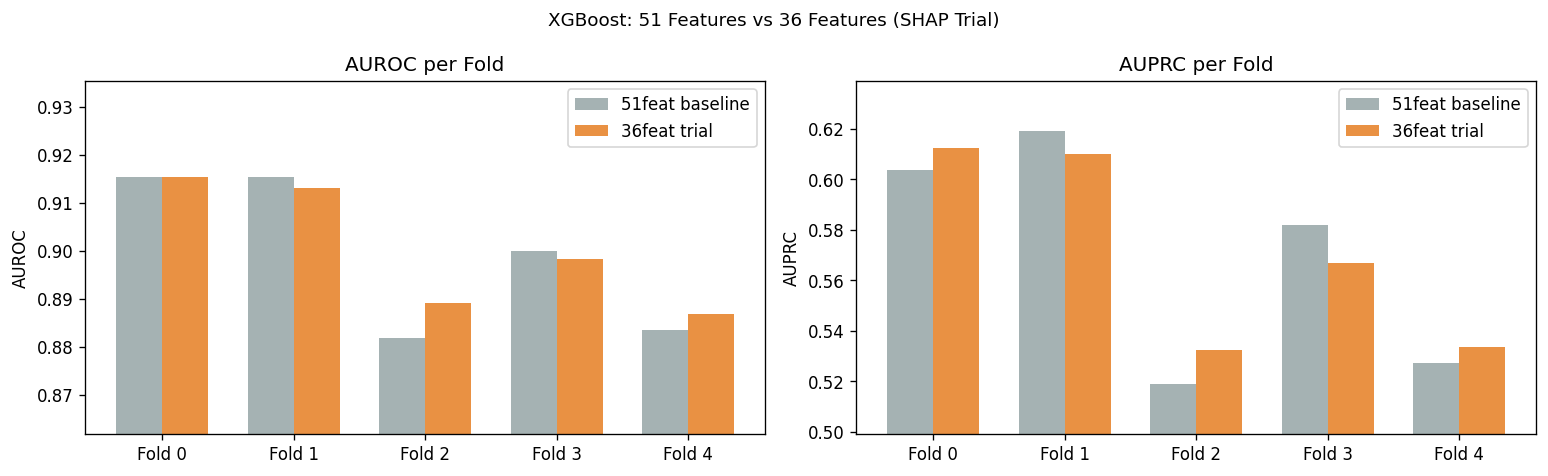

In [15]:
print('=== Trial: XGBoost 36 Features (SHAP 상위 36개) ===')

# SHAP 순위 상위 36개
features_36 = shap_importance['feature'].tolist()[:36]
print(f'선택 피처 ({len(features_36)}개):')
for i, f in enumerate(features_36):
    shap_val = shap_importance.loc[shap_importance['feature']==f, 'mean_abs_shap'].values[0]
    print(f'  {i+1:2d}. {f}: SHAP={shap_val:.4f}')

X_36 = df_features[features_36].values
oof_36 = np.zeros(len(df_features))
fold_metrics_36 = []
models_36 = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_36, y, groups)):
    X_tr, X_val = X_36[train_idx], X_36[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=features_36)
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=features_36)

    model = xgb.train(
        xgb_params, dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    val_pred = model.predict(dval)
    oof_36[val_idx] = val_pred
    models_36.append(model)

    auroc = roc_auc_score(y_val, val_pred)
    auprc = average_precision_score(y_val, val_pred)
    fold_metrics_36.append({'fold': fold, 'auroc': auroc, 'auprc': auprc,
                             'best_iter': model.best_iteration})
    print(f'  Fold {fold}: AUROC={auroc:.4f}, AUPRC={auprc:.4f} (iter={model.best_iteration})')

auroc_36 = roc_auc_score(y, oof_36)
auprc_36 = average_precision_score(y, oof_36)

print(f'\n=== Trial OOF (36 features) ===')
print(f'  AUROC: {auroc_36:.4f}  (51feat baseline: {baseline_auroc:.4f}, diff: {auroc_36 - baseline_auroc:+.4f})')
print(f'  AUPRC: {auprc_36:.4f}  (51feat baseline: {baseline_auprc:.4f}, diff: {auprc_36 - baseline_auprc:+.4f})')

# 비교 테이블
df_trial_cmp = pd.DataFrame({
    'Model':   ['XGBoost 51feat (baseline)', 'XGBoost 36feat (trial)'],
    'N_feat':  [len(feature_cols), len(features_36)],
    'AUROC':   [baseline_auroc, auroc_36],
    'AUPRC':   [baseline_auprc, auprc_36],
})
print(f'\n{df_trial_cmp.to_string(index=False)}')

# Fold별 비교
df_36 = pd.DataFrame(fold_metrics_36)
df_51 = pd.DataFrame(fold_metrics_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
xf = np.arange(N_SPLITS)
bw = 0.35

for ax, metric, title in zip(axes, ['auroc', 'auprc'], ['AUROC per Fold', 'AUPRC per Fold']):
    ax.bar(xf - bw/2, df_51[metric], bw, label='51feat baseline', color='#95a5a6', alpha=0.85)
    ax.bar(xf + bw/2, df_36[metric], bw, label='36feat trial',    color='#e67e22', alpha=0.85)
    ax.set_xticks(xf)
    ax.set_xticklabels([f'Fold {i}' for i in range(N_SPLITS)])
    ax.set_title(title)
    ax.set_ylabel(metric.upper())
    ax.legend()
    mn = min(df_51[metric].min(), df_36[metric].min())
    mx = max(df_51[metric].max(), df_36[metric].max())
    ax.set_ylim(mn - 0.02, mx + 0.02)

plt.suptitle('XGBoost: 51 Features vs 36 Features (SHAP Trial)', fontsize=11)
plt.tight_layout()
plt.show()

## Step 7: 최종 SHAP + ROC / PR Curve

=== 최종 모델 SHAP ===


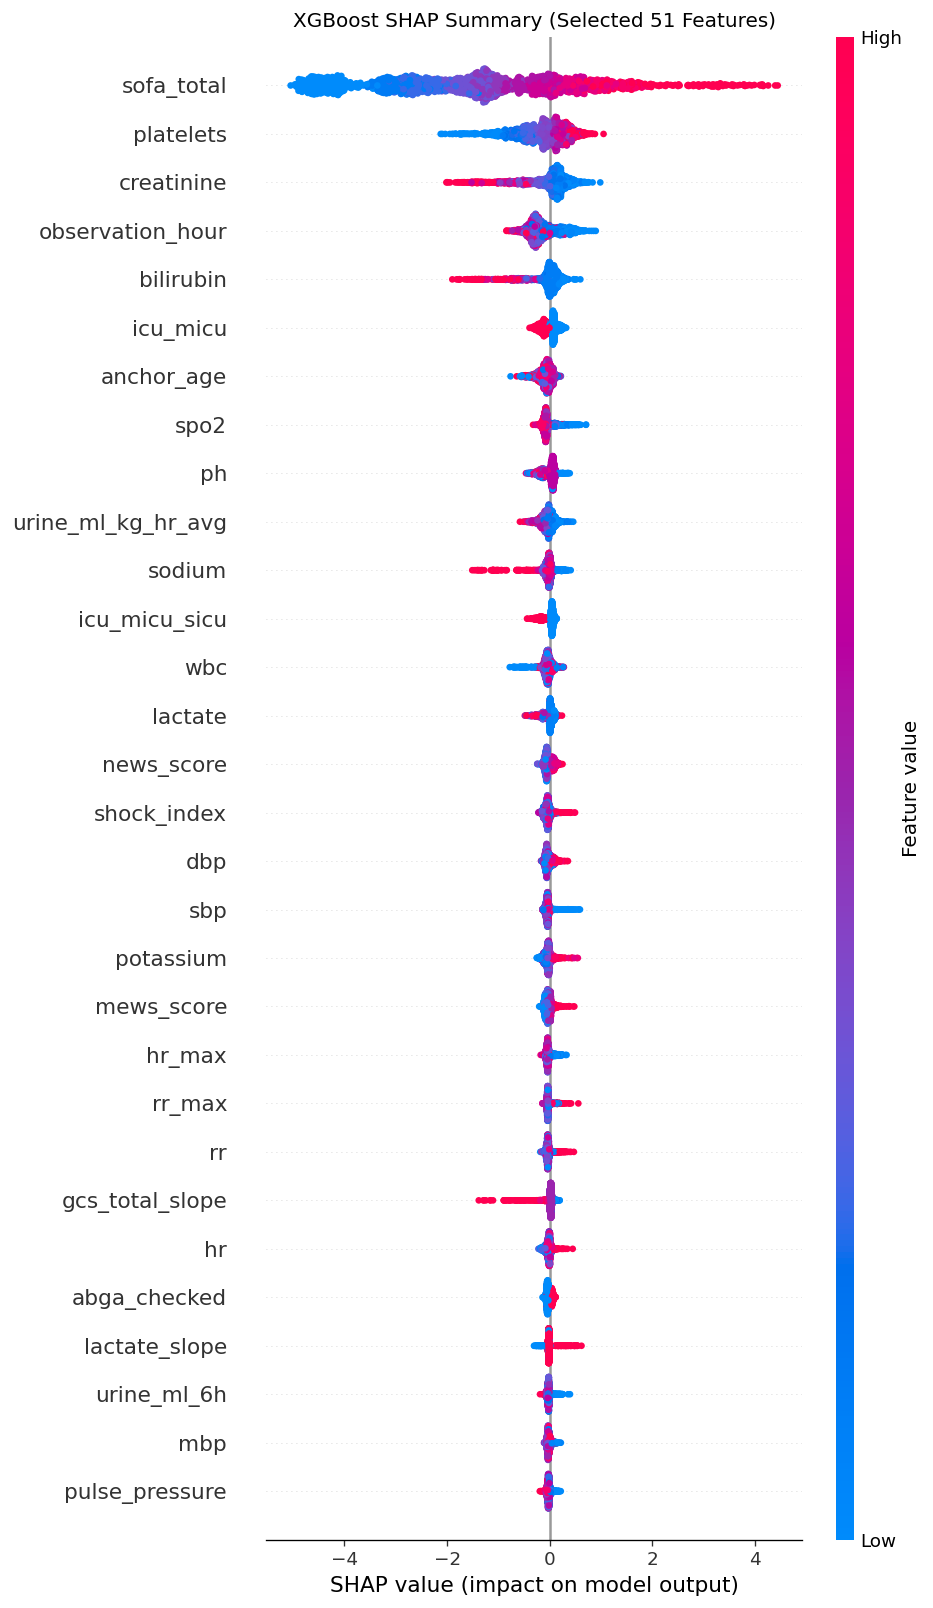

In [22]:
# 최종 모델 SHAP
# --- 안전장치: 중간 실행 지원 ---
if "Path" not in globals():
    from pathlib import Path
if "pd" not in globals():
    import pandas as pd
if "np" not in globals():
    import numpy as np
if "plt" not in globals():
    import matplotlib.pyplot as plt
if "shap" not in globals():
    import shap
if "GroupKFold" not in globals():
    from sklearn.model_selection import GroupKFold

if "PROCESSED_DIR" not in globals():
    DATA_DIR = Path("../data")
    PROCESSED_DIR = DATA_DIR / "processed"
if "TARGET" not in globals():
    TARGET = "composite_next_24h"

# 데이터가 없으면 로드
if "df_features" not in globals() or "df_labels" not in globals():
    df_features = pd.read_csv(PROCESSED_DIR / "features_final.csv")
    df_labels = pd.read_csv(PROCESSED_DIR / "labels_final.csv")

    # 중복 컬럼 제거 (observation_hour.1 등)
    obs_hour_dups = [c for c in df_features.columns if c.startswith("observation_hour.")]
    if obs_hour_dups:
        df_features = df_features.drop(columns=obs_hour_dups)

    # leakage 컬럼 제거
    if "icu_mortality" in df_features.columns:
        df_features = df_features.drop(columns=["icu_mortality"])

if "feature_cols" not in globals():
    feature_cols = df_features.columns.tolist()

if "X" not in globals():
    X = df_features[feature_cols].values
if "y" not in globals():
    y = df_labels[TARGET].values
if "groups" not in globals():
    if "stay_id" not in df_labels.columns:
        raise KeyError("labels_final.csv에 stay_id 컬럼이 없습니다.")
    groups = df_labels["stay_id"].values

if "N_SPLITS" not in globals():
    N_SPLITS = 5
if "gkf" not in globals():
    gkf = GroupKFold(n_splits=N_SPLITS)

if "final_features" not in globals():
    final_features = feature_cols

if "models_final" not in globals():
    if "models_all" in globals():
        models_final = models_all
    else:
        import pickle
        if "DATA_DIR" not in globals():
            DATA_DIR = Path("../data")
        model_path = DATA_DIR / "models" / "xgb_final_models.pkl"
        if model_path.exists():
            with open(model_path, "rb") as f:
                models_final = pickle.load(f)
        else:
            raise FileNotFoundError(
                "models_final이 없고, 저장된 모델도 없습니다. "
                "앞 셀을 실행하거나 DATA/models/xgb_final_models.pkl을 준비하세요."
            )

if "last_fold_val_idx" not in globals():
    last_fold_val_idx = list(gkf.split(X, y, groups))[-1][1]

print('=== 최종 모델 SHAP ===')
X_shap_final = df_features.iloc[last_fold_val_idx][final_features]
X_shap_final_sample = X_shap_final.sample(min(2000, len(X_shap_final)), random_state=42)

explainer_final = shap.TreeExplainer(models_final[-1])
shap_values_final = explainer_final.shap_values(X_shap_final_sample)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_final, X_shap_final_sample,
                  feature_names=final_features, max_display=30, show=False)
plt.title(f'XGBoost SHAP Summary (Selected {len(final_features)} Features)')
plt.tight_layout()
plt.show()


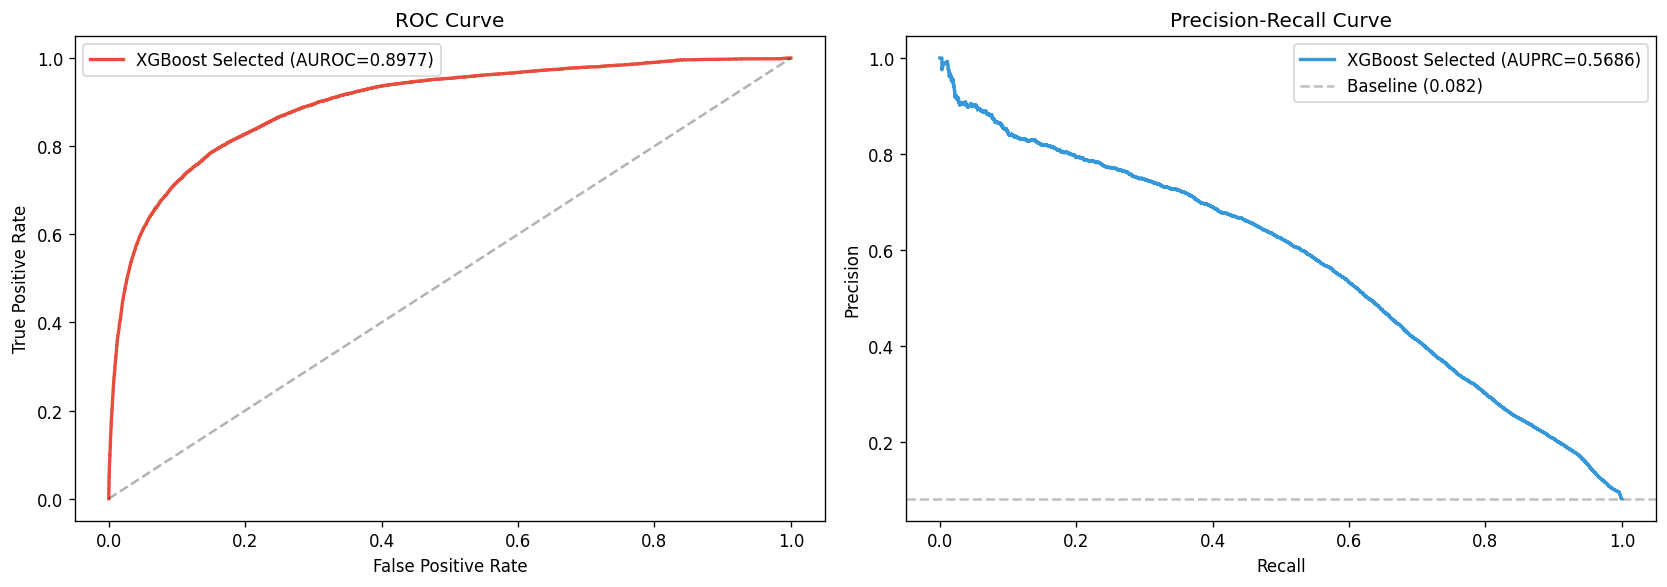

In [23]:
# ROC / PR Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y, oof_final)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'XGBoost Selected (AUROC={final_auroc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y, oof_final)
axes[1].plot(rec, prec, color='#3498db', lw=2,
             label=f'XGBoost Selected (AUPRC={final_auprc:.4f})')
axes[1].axhline(pos_rate, color='gray', linestyle='--', alpha=0.5,
                label=f'Baseline ({pos_rate:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 8: LightGBM 학습 (XGBoost와 동일 조건 비교)

> 동일 GroupKFold / 동일 피처셋으로 LightGBM을 학습해 XGBoost와 직접 비교합니다.

In [24]:
import lightgbm as lgb

# --- LightGBM 파라미터 ---
lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         7,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'scale_pos_weight':  scale_pos,
    'random_state':      42,
    'verbose':          -1,
    'n_jobs':           -1,
}

# 8-1) Baseline (전체 피처, 3-fold 빠른 버전)
print('=== LightGBM Baseline (전체 피처, 3-fold) ===')
gkf3 = GroupKFold(n_splits=3)

X_all = df_features[feature_cols].values
lgb_oof_all = np.zeros(len(df_features))
lgb_fold_metrics_all = []

for fold, (train_idx, val_idx) in enumerate(gkf3.split(X_all, y, groups)):
    X_tr, X_val = X_all[train_idx], X_all[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feature_cols)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=feature_cols, reference=dtrain)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=400,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
    )

    val_pred = model.predict(X_val)
    lgb_oof_all[val_idx] = val_pred

    auroc = roc_auc_score(y_val, val_pred)
    auprc = average_precision_score(y_val, val_pred)
    lgb_fold_metrics_all.append({'fold': fold, 'auroc': auroc, 'auprc': auprc,
                                  'best_iter': model.best_iteration})
    print(f'  Fold {fold}: AUROC={auroc:.4f}, AUPRC={auprc:.4f} (iter={model.best_iteration})')

val_mask = lgb_oof_all > 0
lgb_baseline_auroc = roc_auc_score(y[val_mask], lgb_oof_all[val_mask])
lgb_baseline_auprc = average_precision_score(y[val_mask], lgb_oof_all[val_mask])
print(f'\nLGBM Baseline OOF: AUROC={lgb_baseline_auroc:.4f}, AUPRC={lgb_baseline_auprc:.4f}')

=== LightGBM Baseline (전체 피처, 3-fold) ===
  Fold 0: AUROC=0.8971, AUPRC=0.5546 (iter=213)
  Fold 1: AUROC=0.8801, AUPRC=0.5217 (iter=38)
  Fold 2: AUROC=0.9134, AUPRC=0.6039 (iter=132)

LGBM Baseline OOF: AUROC=0.8937, AUPRC=0.5426


In [ ]:
# 8-2) LightGBM — 선정 피처 (31개, 3-fold)
print('=== LightGBM Selected (선정 피처, 3-fold) ===')

X_sel = df_features[final_features].values
lgb_oof_sel = np.zeros(len(df_features))
lgb_fold_metrics_sel = []
lgb_models_sel = []

for fold, (train_idx, val_idx) in enumerate(gkf3.split(X_sel, y, groups)):
    X_tr, X_val = X_sel[train_idx], X_sel[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=final_features)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=final_features, reference=dtrain)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=400,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
    )

    val_pred = model.predict(X_val)
    lgb_oof_sel[val_idx] = val_pred
    lgb_models_sel.append(model)

    auroc = roc_auc_score(y_val, val_pred)
    auprc = average_precision_score(y_val, val_pred)
    lgb_fold_metrics_sel.append({'fold': fold, 'auroc': auroc, 'auprc': auprc,
                                  'best_iter': model.best_iteration})
    print(f'  Fold {fold}: AUROC={auroc:.4f}, AUPRC={auprc:.4f} (iter={model.best_iteration})')

val_mask_sel = lgb_oof_sel > 0
lgb_selected_auroc = roc_auc_score(y[val_mask_sel], lgb_oof_sel[val_mask_sel])
lgb_selected_auprc = average_precision_score(y[val_mask_sel], lgb_oof_sel[val_mask_sel])
print(f'\nLGBM Selected OOF: AUROC={lgb_selected_auroc:.4f}, AUPRC={lgb_selected_auprc:.4f}')

=== LightGBM Selected (선정 피처, 3-fold) ===
  Fold 0: AUROC=0.8966, AUPRC=0.5409 (iter=111)
  Fold 1: AUROC=0.8767, AUPRC=0.5174 (iter=74)
  Fold 2: AUROC=0.9109, AUPRC=0.5929 (iter=116)

LGBM Selected OOF: AUROC=0.8946, AUPRC=0.5454


=== XGBoost vs LightGBM 비교 ===
             Model  Features    AUROC    AUPRC
 XGBoost (51 feat)        51 0.897687 0.568561
LightGBM (51 feat)        51 0.894642 0.545403


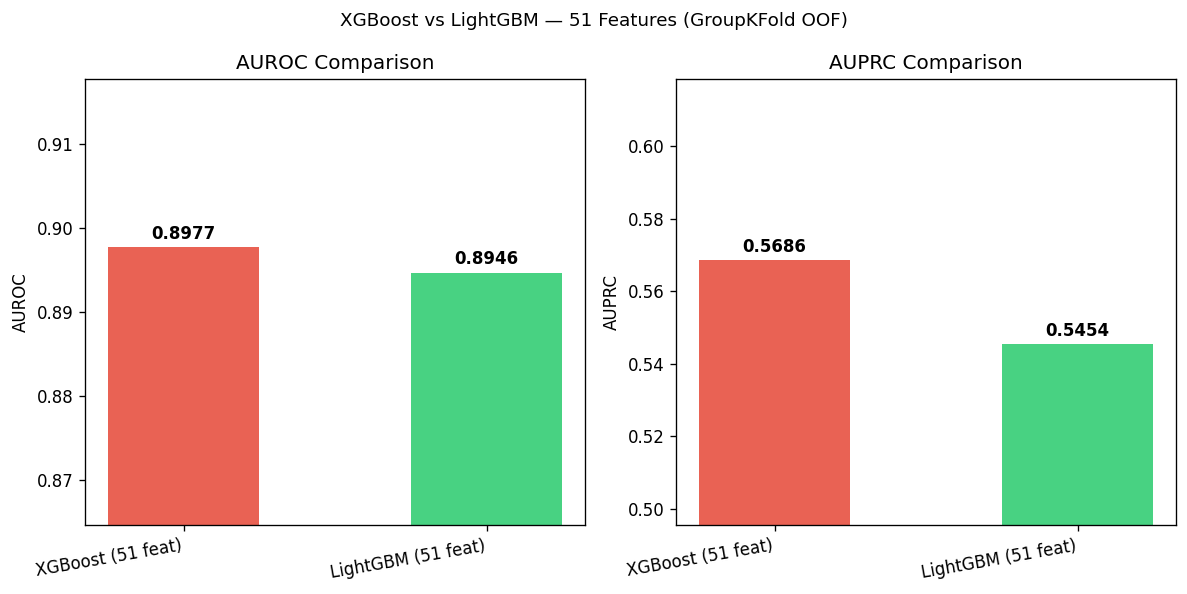

⚠️  fold metrics가 없어 Fold별 비교는 건너뜁니다. (앞 셀 실행 필요)


In [26]:
# --- XGBoost vs LightGBM 비교 (전체 51개 피처 기준) ---
# --- 안전장치: 중간 실행 지원 ---
if "Path" not in globals():
    from pathlib import Path
if "pd" not in globals():
    import pandas as pd
if "np" not in globals():
    import numpy as np
if "roc_auc_score" not in globals() or "average_precision_score" not in globals():
    from sklearn.metrics import roc_auc_score, average_precision_score

if "DATA_DIR" not in globals():
    DATA_DIR = Path("../data")
if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = DATA_DIR / "processed"
if "TARGET" not in globals():
    TARGET = "composite_next_24h"

# 데이터/피처 확보
if "df_features" not in globals() or "df_labels" not in globals():
    df_features = pd.read_csv(PROCESSED_DIR / "features_final.csv")
    df_labels = pd.read_csv(PROCESSED_DIR / "labels_final.csv")

    obs_hour_dups = [c for c in df_features.columns if c.startswith("observation_hour.")]
    if obs_hour_dups:
        df_features = df_features.drop(columns=obs_hour_dups)

    if "icu_mortality" in df_features.columns:
        df_features = df_features.drop(columns=["icu_mortality"])

if "feature_cols" not in globals():
    feature_cols = df_features.columns.tolist()

if "y" not in globals():
    y = df_labels[TARGET].values

# XGBoost 최종 성능 확보
if "final_auroc" not in globals() or "final_auprc" not in globals():
    if "oof_final" in globals():
        final_auroc = roc_auc_score(y, oof_final)
        final_auprc = average_precision_score(y, oof_final)
    else:
        xgb_oof_path = DATA_DIR / "models" / "xgb_oof_prob.npy"
        if xgb_oof_path.exists():
            oof_final = np.load(xgb_oof_path)
            final_auroc = roc_auc_score(y, oof_final)
            final_auprc = average_precision_score(y, oof_final)
        else:
            raise FileNotFoundError(
                "final_auroc/final_auprc 계산에 필요한 OOF가 없습니다. "
                "앞 셀을 실행하거나 DATA/models/xgb_oof_prob.npy를 준비하세요."
            )

# LightGBM 선정 피처 성능 확보
if "lgb_selected_auroc" not in globals() or "lgb_selected_auprc" not in globals():
    if "lgb_oof_sel" in globals():
        mask = lgb_oof_sel > 0
        lgb_selected_auroc = roc_auc_score(y[mask], lgb_oof_sel[mask])
        lgb_selected_auprc = average_precision_score(y[mask], lgb_oof_sel[mask])
    else:
        lgb_oof_path = DATA_DIR / "models" / "lgb_oof_prob.npy"
        if lgb_oof_path.exists():
            lgb_oof_sel = np.load(lgb_oof_path)
            mask = lgb_oof_sel > 0
            lgb_selected_auroc = roc_auc_score(y[mask], lgb_oof_sel[mask])
            lgb_selected_auprc = average_precision_score(y[mask], lgb_oof_sel[mask])
        else:
            raise FileNotFoundError(
                "LightGBM OOF가 없습니다. "
                "LightGBM 셀을 실행하거나 DATA/models/lgb_oof_prob.npy를 준비하세요."
            )

comparison = pd.DataFrame({
    'Model':     [f'XGBoost ({len(feature_cols)} feat)', f'LightGBM ({len(feature_cols)} feat)'],
    'Features':  [len(feature_cols), len(feature_cols)],
    'AUROC':     [final_auroc, lgb_selected_auroc],
    'AUPRC':     [final_auprc, lgb_selected_auprc],
})

print('=== XGBoost vs LightGBM 비교 ===')
print(comparison.to_string(index=False))

# 바 차트
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['#e74c3c', '#2ecc71']
x = np.arange(len(comparison))
w = 0.5

for ax, metric, title, ylim in zip(
    axes,
    ['AUROC', 'AUPRC'],
    ['AUROC Comparison', 'AUPRC Comparison'],
    [(max(comparison['AUROC'].min() - 0.03, 0.0), min(comparison['AUROC'].max() + 0.02, 1.0)),
     (max(comparison['AUPRC'].min() - 0.05, 0.0), min(comparison['AUPRC'].max() + 0.05, 1.0))],
):
    bars = ax.bar(x, comparison[metric], width=w, color=colors, alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Model'], rotation=10, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    for bar, v in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (ylim[1]-ylim[0])*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle(f'XGBoost vs LightGBM — {len(feature_cols)} Features (GroupKFold OOF)', fontsize=11)
plt.tight_layout()
plt.show()

# 폴드별 비교 (가능할 때만)
if "fold_metrics_final" in globals() and "lgb_fold_metrics_sel" in globals():
    df_xgb_sel = pd.DataFrame(fold_metrics_final)
    df_lgb_sel  = pd.DataFrame(lgb_fold_metrics_sel)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    xf_xgb = np.arange(len(df_xgb_sel))
    xf_lgb = np.arange(len(df_lgb_sel))
    bw = 0.35

    for ax, metric, title in zip(axes, ['auroc', 'auprc'], ['AUROC per Fold', 'AUPRC per Fold']):
        ax.bar(xf_xgb - bw/2, df_xgb_sel[metric], bw,
               label=f'XGBoost ({len(df_xgb_sel)}-fold)', color='#e74c3c', alpha=0.85)
        ax.bar(xf_lgb + bw/2, df_lgb_sel[metric], bw,
               label=f'LightGBM ({len(df_lgb_sel)}-fold)', color='#2ecc71', alpha=0.85)
        ax.set_xticks(np.arange(max(len(df_xgb_sel), len(df_lgb_sel))))
        ax.set_xticklabels([f'Fold {i}' for i in range(max(len(df_xgb_sel), len(df_lgb_sel)))])
        ax.set_title(title)
        ax.set_ylabel(metric.upper())
        ax.legend()
        mn = min(df_xgb_sel[metric].min(), df_lgb_sel[metric].min())
        mx = max(df_xgb_sel[metric].max(), df_lgb_sel[metric].max())
        ax.set_ylim(mn - 0.02, mx + 0.02)

    plt.suptitle(f'XGBoost vs LightGBM — {len(feature_cols)} Features, Fold별', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  fold metrics가 없어 Fold별 비교는 건너뜁니다. (앞 셀 실행 필요)')


In [27]:
print('\n' + '='*60)
print('=== 12. XGBoost + LightGBM 완료 ===')
print('='*60)

print(f'\n[XGBoost Baseline ({len(feature_cols)}개 피처)]')
print(f'  eval_metric : auc')
print(f'  OOF AUROC   : {baseline_auroc:.4f}')
print(f'  OOF AUPRC   : {baseline_auprc:.4f}')

print(f'\n[XGBoost Selected ({len(final_features)}개 피처)]')
print(f'  OOF AUROC   : {final_auroc:.4f}  (diff: {final_auroc - baseline_auroc:+.4f})')
print(f'  OOF AUPRC   : {final_auprc:.4f}  (diff: {final_auprc - baseline_auprc:+.4f})')

print(f'\n[LightGBM Selected ({len(final_features)}개 피처)]')
print(f'  OOF AUROC   : {lgb_selected_auroc:.4f}')
print(f'  OOF AUPRC   : {lgb_selected_auprc:.4f}')

print(f'\n[leakage 처리]')
print(f'  icu_mortality: features_final.csv에서 제거됨 (temporal leakage)')
print(f'\n-> 저장 파일: xgb_final_models.pkl / lgb_final_models.pkl / model_comparison.csv')
print('='*60)


=== 12. XGBoost + LightGBM 완료 ===

[XGBoost Baseline (51개 피처)]
  eval_metric : auc
  OOF AUROC   : 0.8977
  OOF AUPRC   : 0.5686

[XGBoost Selected (51개 피처)]
  OOF AUROC   : 0.8977  (diff: +0.0000)
  OOF AUPRC   : 0.5686  (diff: +0.0000)

[LightGBM Selected (51개 피처)]
  OOF AUROC   : 0.8946
  OOF AUPRC   : 0.5454

[leakage 처리]
  icu_mortality: features_final.csv에서 제거됨 (temporal leakage)

-> 저장 파일: xgb_final_models.pkl / lgb_final_models.pkl / model_comparison.csv


#### 피처 구성 선정 

AUROC: 0.895697 vs 0.894668
차이: +0.001029 (51개 우세)
AUPRC: 0.568919 vs 0.555653
차이: +0.013266 (51개 우세)

피처 차이 간 (51 features vs. 31 features) AUROC 차이는 매우 작고,
반면, AUPRC는 51 피처 구성 버전의 모델 성능이 의미있게 더 높게 나타나기 때문에 양성탐지를 위해 
PRC가 더 높은 기존 51 피처 구성을 선택


## Step 0 (추가): 모델 / OOF / 피처 저장

> 13번 노트북(Risk Scoring)에서 사용할 모델, OOF 확률값, 선정 피처 리스트를 저장합니다.

In [3]:
import pickle
if "Path" not in globals():
    from pathlib import Path
if "np" not in globals():
    import numpy as np
if "pd" not in globals():
    import pandas as pd

if "DATA_DIR" not in globals():
    DATA_DIR = Path("../data")
MODEL_DIR = Path("..") / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── XGBoost ───────────────────────────────────────────────
if "models_final" in globals():
    with open(MODEL_DIR / 'xgb_final_models.pkl', 'wb') as f:
        pickle.dump(models_final, f)
    print(f'✔ xgb_final_models.pkl ({len(models_final)} folds)')
else:
    print('⚠️  models_final 없음 → xgb_final_models.pkl 저장 생략')

if "oof_final" in globals():
    np.save(MODEL_DIR / 'xgb_oof_prob.npy', oof_final)
    print(f'✔ xgb_oof_prob.npy  (shape={oof_final.shape})')
else:
    print('⚠️  oof_final 없음 → xgb_oof_prob.npy 저장 생략')

# ── LightGBM ──────────────────────────────────────────────
if "lgb_models_sel" in globals():
    with open(MODEL_DIR / 'lgb_final_models.pkl', 'wb') as f:
        pickle.dump(lgb_models_sel, f)
    print(f'✔ lgb_final_models.pkl ({len(lgb_models_sel)} folds)')
else:
    print('⚠️  lgb_models_sel 없음 → lgb_final_models.pkl 저장 생략')

if "lgb_oof_sel" in globals():
    np.save(MODEL_DIR / 'lgb_oof_prob.npy', lgb_oof_sel)
    print(f'✔ lgb_oof_prob.npy  (shape={lgb_oof_sel.shape})')
else:
    print('⚠️  lgb_oof_sel 없음 → lgb_oof_prob.npy 저장 생략')

# ── 피처 리스트 ────────────────────────────────────────────
if "final_features" in globals() and "PROCESSED_DIR" in globals():
    pd.Series(final_features, name='feature').to_frame().to_csv(
        PROCESSED_DIR / 'xgb_selected_features.csv', index=False)
    print(f'✔ xgb_selected_features.csv ({len(final_features)}개)')
else:
    print('⚠️  final_features/PROCESSED_DIR 없음 → xgb_selected_features.csv 저장 생략')

# ── 최종 성능 비교 저장 ────────────────────────────────────
if all(k in globals() for k in ["final_auroc", "final_auprc", "lgb_selected_auroc", "lgb_selected_auprc", "final_features"]):
    results = pd.DataFrame({
        'model':    ['XGBoost', 'LightGBM'],
        'features': [len(final_features), len(final_features)],
        'oof_auroc': [final_auroc, lgb_selected_auroc],
        'oof_auprc': [final_auprc, lgb_selected_auprc],
    })
    results.to_csv(MODEL_DIR / 'model_comparison.csv', index=False)
    print(f'✔ model_comparison.csv')

    # ── 최종 모델 결정 ─────────────────────────────────────────
    best_model = results.loc[results['oof_auroc'].idxmax(), 'model']
    best_auroc  = results['oof_auroc'].max()
    best_auprc  = results.loc[results['oof_auroc'].idxmax(), 'oof_auprc']

    print(f'\n=== 최종 확정 모델: {best_model} ===')
    print(f'  AUROC : {best_auroc:.4f}')
    print(f'  AUPRC : {best_auprc:.4f}')
    print(f'  피처  : {len(final_features)}개')
    print(results.to_string(index=False))

    # best_model_name 저장 (다음 노트북에서 사용)
    with open(MODEL_DIR / 'best_model.txt', 'w') as f:
        f.write(best_model)
    print(f'best_model.txt → "{best_model}"')
else:
    print('⚠️  성능 지표가 부족해 model_comparison/best_model 저장 생략')


⚠️  models_final 없음 → xgb_final_models.pkl 저장 생략
⚠️  oof_final 없음 → xgb_oof_prob.npy 저장 생략
⚠️  lgb_models_sel 없음 → lgb_final_models.pkl 저장 생략
⚠️  lgb_oof_sel 없음 → lgb_oof_prob.npy 저장 생략
⚠️  final_features/PROCESSED_DIR 없음 → xgb_selected_features.csv 저장 생략
⚠️  성능 지표가 부족해 model_comparison/best_model 저장 생략
